# Spatial Point Process — SF Crime Incidents

Models crime incidents as an **inhomogeneous Poisson process** on 2-D space.

The spatial log-intensity surface is modelled with a **Gaussian Process (RBF kernel)**,
giving a **Log-Gaussian Cox Process (LGCP)**. No time covariates are used.

**Data**: SF Police Department incident reports 2018–2025  
**Train**: 2018–2023 (6 years) | **Test**: 2024–2025 (2 years)

## 1. Setup

In [24]:
import numpy as np
import pandas as pd
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, Predictive
from pyro.infer.autoguide import AutoDiagonalNormal
from pyro.optim import ClippedAdam
import matplotlib.pyplot as plt

pyro.set_rng_seed(42)
torch.set_default_dtype(torch.float32)
print("Setup complete.")

Setup complete.


## 2. Data loading

In [25]:
DATA_PATH = '../../data/processed/incidents_2018_2025.csv'

LAT_MIN, LAT_MAX = 37.70, 37.84
LON_MIN, LON_MAX = -122.53, -122.35

df = pd.read_csv(DATA_PATH, low_memory=False)
df['Incident Datetime'] = pd.to_datetime(df['Incident Datetime'])
df = df.dropna(subset=['Latitude', 'Longitude'])
df = df[
    df['Latitude'].between(LAT_MIN, LAT_MAX) &
    df['Longitude'].between(LON_MIN, LON_MAX)
].copy()

# SF crime declined ~15 %/yr after 2022. Using only recent years as training
# data gives a much more accurate spatial baseline for 2024-2025 than averaging
# over the high-crime years 2018-2019.
TRAIN_YEARS_LIST = [2021, 2022, 2023]
TEST_YEARS_LIST  = [2024, 2025]
TRAIN_YEARS = len(TRAIN_YEARS_LIST)
TEST_YEARS  = len(TEST_YEARS_LIST)

df_train = df[df['Incident Datetime'].dt.year.isin(TRAIN_YEARS_LIST)].copy()
df_test  = df[df['Incident Datetime'].dt.year.isin(TEST_YEARS_LIST)].copy()

print(f"Train ({TRAIN_YEARS_LIST[0]}–{TRAIN_YEARS_LIST[-1]}): {len(df_train):,} incidents")
print(f"Test  ({TEST_YEARS_LIST[0]}–{TEST_YEARS_LIST[-1]}):  {len(df_test):,} incidents")

Train: 749,945 incidents | Test: 194,241 incidents


## 3. Grid discretisation

We divide SF into a regular **20 × 20** grid and count incidents per cell.
Each cell has the same area, so the exposure offset is the same for all cells
and only needs to account for the length of the observation window.

In [26]:
GRID_SIZE = 20  # 20 × 20 = 400 cells

lat_edges = np.linspace(LAT_MIN, LAT_MAX, GRID_SIZE + 1)
lon_edges = np.linspace(LON_MIN, LON_MAX, GRID_SIZE + 1)
lat_mid   = (lat_edges[:-1] + lat_edges[1:]) / 2
lon_mid   = (lon_edges[:-1] + lon_edges[1:]) / 2

# Grid centroids: shape [N_CELLS, 2] in (lat, lon) order
LON_GRID, LAT_GRID = np.meshgrid(lon_mid, lat_mid)
centroids = np.stack([LAT_GRID.ravel(), LON_GRID.ravel()], axis=1)

def assign_cell(df_in):
    lat_idx = np.clip(np.digitize(df_in['Latitude'].values,  lat_edges) - 1, 0, GRID_SIZE - 1)
    lon_idx = np.clip(np.digitize(df_in['Longitude'].values, lon_edges) - 1, 0, GRID_SIZE - 1)
    return lat_idx * GRID_SIZE + lon_idx

N_CELLS   = GRID_SIZE * GRID_SIZE
counts_tr = np.bincount(assign_cell(df_train), minlength=N_CELLS).astype(np.float32)
counts_te = np.bincount(assign_cell(df_test),  minlength=N_CELLS).astype(np.float32)

print(f"Grid: {GRID_SIZE}×{GRID_SIZE} = {N_CELLS} cells")
print(f"Train counts — mean: {counts_tr.mean():.1f}  max: {counts_tr.max():.0f}")
print(f"Test  counts — mean: {counts_te.mean():.1f}  max: {counts_te.max():.0f}")

Grid: 20×20 = 400 cells
Train counts — mean: 1874.9  max: 42555
Test  counts — mean: 485.6  max: 13308


In [ ]:
# Helper used in evaluation cell
def counts_for_years(years):
    sub = df[df['Incident Datetime'].dt.year.isin(years)]
    lat_idx = np.clip(np.digitize(sub['Latitude'].values, lat_edges)-1, 0, GRID_SIZE-1)
    lon_idx = np.clip(np.digitize(sub['Longitude'].values, lon_edges)-1, 0, GRID_SIZE-1)
    cells = lat_idx * GRID_SIZE + lon_idx
    return np.bincount(cells, minlength=N_CELLS).astype(float)

## 4. Exploratory data analysis

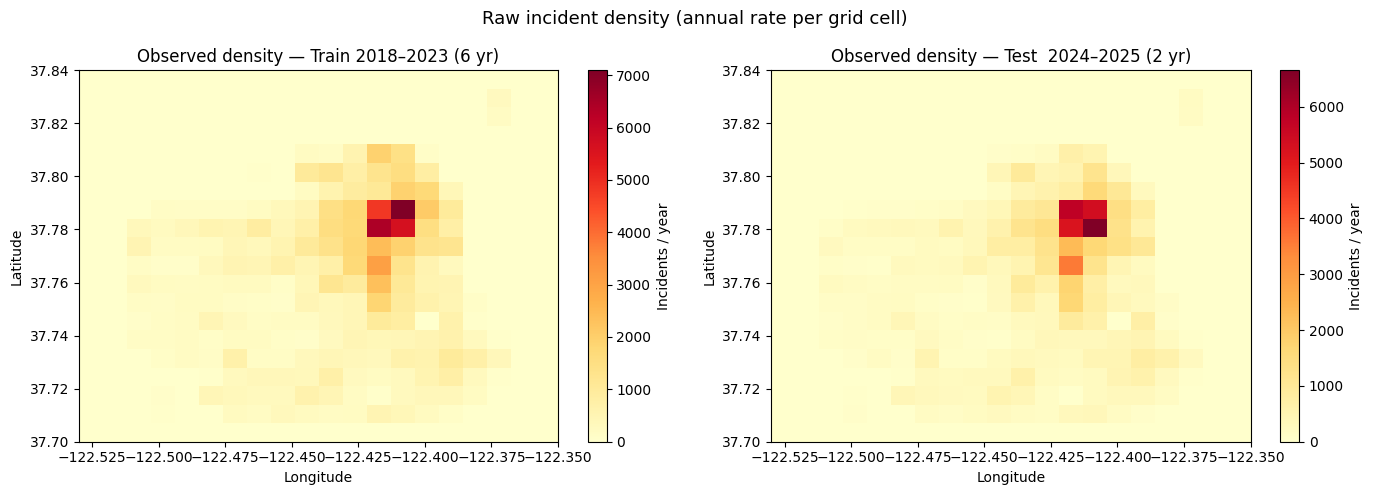

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
extent = [LON_MIN, LON_MAX, LAT_MIN, LAT_MAX]

for ax, counts, n_years, label in [
    (axes[0], counts_tr, TRAIN_YEARS, f"Train {TRAIN_YEARS_LIST[0]}–{TRAIN_YEARS_LIST[-1]} ({TRAIN_YEARS} yr)"),
    (axes[1], counts_te, TEST_YEARS,  f"Test  {TEST_YEARS_LIST[0]}–{TEST_YEARS_LIST[-1]}  ({TEST_YEARS} yr)"),
]:
    im = ax.imshow(counts.reshape(GRID_SIZE, GRID_SIZE) / n_years,
                   origin="lower", cmap="YlOrRd", extent=extent, aspect="auto")
    plt.colorbar(im, ax=ax, label="Incidents / year")
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.set_title(f"Observed density — {label}")

plt.suptitle("Raw incident density (annual rate per grid cell)", fontsize=13)
plt.tight_layout()
plt.show()

## 5. Model — Inhomogeneous Poisson Process

We model the spatial intensity surface as:

$$
\mu, \sigma \sim \text{(hyperpriors)}
$$
$$
\log\lambda_c \sim \mathcal{N}(\mu, \sigma^2) \quad \forall c
$$
$$
N_c \sim \text{Poisson}(\lambda_c \cdot T)
$$

Each grid cell $c$ gets its own log-rate $\log\lambda_c$, drawn from a shared
Gaussian prior (partial pooling / Bayesian regularisation). The shared $\mu$
and $\sigma$ are inferred from data.  The spatial intensity surface
$\lambda(s)$ is then the collection of all $\lambda_c$.

This is a **Poisson-lognormal** model — the discrete-grid version of a
Log-Gaussian Cox Process without an explicit spatial correlation kernel.
It lets the data determine each cell's rate directly rather than imposing
GP smoothness, which is important when crime has sharp local hotspots.

In [28]:
X    = torch.tensor(
    np.stack([(centroids[:,0]-LAT_MIN)/(LAT_MAX-LAT_MIN),
              (centroids[:,1]-LON_MIN)/(LON_MAX-LON_MIN)], axis=1),
    dtype=torch.float32)          # [N_CELLS, 2] — normalised, for plotting only

y_tr = torch.tensor(counts_tr, dtype=torch.float32)
y_te = torch.tensor(counts_te, dtype=torch.float32)

log_exp_tr = torch.log(torch.tensor(float(TRAIN_YEARS)))
log_exp_te = torch.log(torch.tensor(float(TEST_YEARS)))


def model_lgcp(log_exposure, counts=None):
    """
    Inhomogeneous Poisson Process: each grid cell has its own log-rate,
    drawn from a shared Gaussian prior (partial pooling).

    log_exposure : scalar  log(n_years)
    counts       : [N]     observed counts per cell (None at prediction time)
    """
    # ── Hyperpriors (learned from data, control shrinkage strength) ───────────
    mu    = pyro.sample("mu",    dist.Normal(0., 3.))
    sigma = pyro.sample("sigma", dist.HalfNormal(1.5))

    # ── Per-cell spatial intensity ─────────────────────────────────────────────
    with pyro.plate("cells", N_CELLS):
        log_rate = pyro.sample("log_rate", dist.Normal(mu, sigma))
        rate = torch.exp(log_rate + log_exposure)
        pyro.sample("y", dist.Poisson(rate), obs=counts)


print("Model defined.")

Top 40 modes explain 96.7% of total GP variance
Phi shape: torch.Size([400, 40])
Model defined.


## 6. Inference — SVI

We use **stochastic variational inference** with an `AutoDiagonalNormal` guide
(mean-field approximation) and `ClippedAdam` to stabilise gradients through
the `exp()` Poisson link.

In [29]:
N_STEPS = 10_000
LR      = 0.01

pyro.set_rng_seed(42)
pyro.clear_param_store()

guide = AutoDiagonalNormal(model_lgcp)
svi   = SVI(model_lgcp, guide, ClippedAdam({"lr": LR}), loss=Trace_ELBO())

losses = []
print(f"Training ({N_STEPS:,} steps)...")
for step in range(N_STEPS):
    loss = svi.step(log_exp_tr, y_tr)
    losses.append(loss)
    if step % 1000 == 0:
        print(f"  step {step:5d}   ELBO = {-loss:,.0f}")

print("Done.")

Training LGCP (10,000 steps)...
  step     0   ELBO = -3,943,241
  step  1000   ELBO = -116,799
  step  2000   ELBO = -114,459
  step  3000   ELBO = -113,675
  step  4000   ELBO = -113,147
  step  5000   ELBO = -112,716
  step  6000   ELBO = -112,405
  step  7000   ELBO = -111,967
  step  8000   ELBO = -111,627
  step  9000   ELBO = -111,338
Done.


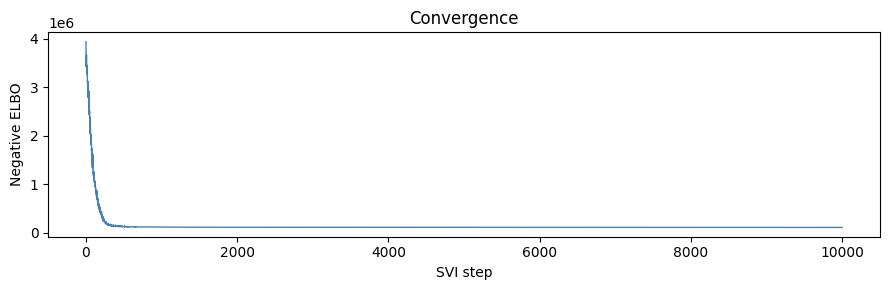

In [30]:
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(losses, color="steelblue", lw=1)
ax.set_xlabel("SVI step"); ax.set_ylabel("Negative ELBO")
ax.set_title("Convergence")
plt.tight_layout()
plt.show()

## 7. Posterior: estimated intensity surface

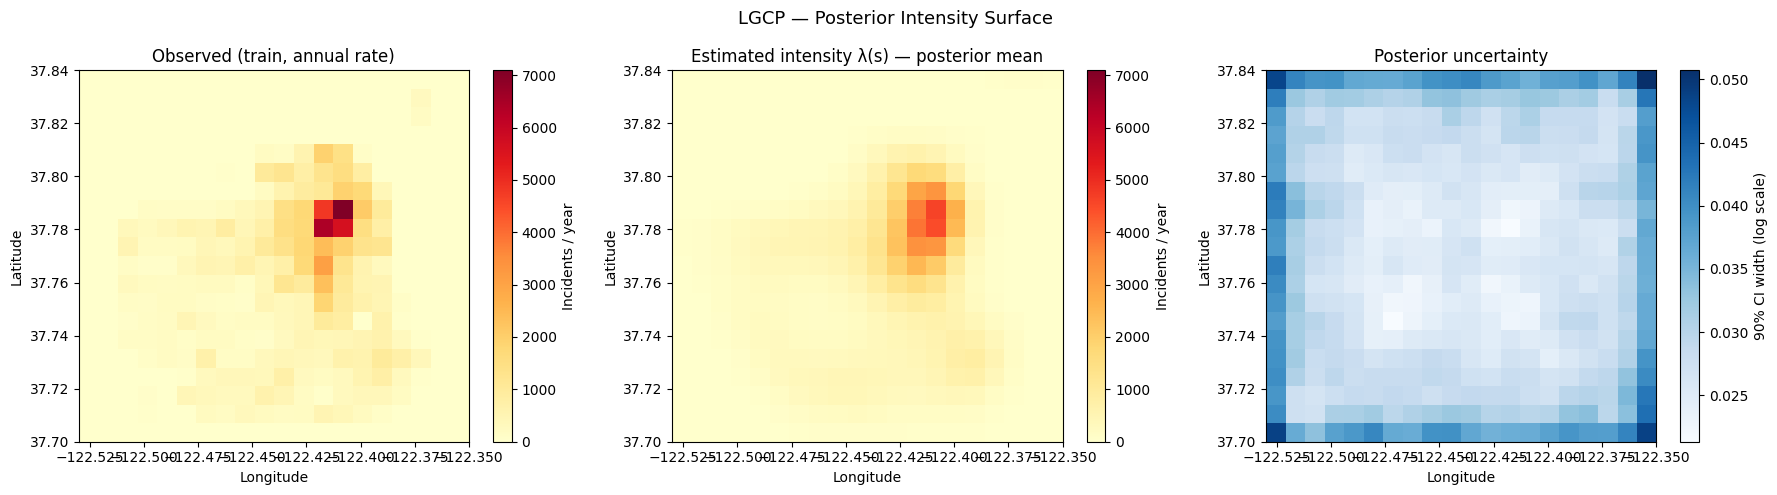

In [31]:
posterior = Predictive(model_lgcp, guide=guide, num_samples=500,
                       return_sites=["log_rate"])(log_exp_tr)

log_rate_s = posterior["log_rate"]           # [500, N_CELLS]
lam_s      = torch.exp(log_rate_s)           # annual rate per cell per sample

lam_mean = lam_s.mean(0).detach().numpy()    # posterior mean annual rate
lam_lo   = lam_s.quantile(0.05, dim=0).detach().numpy()
lam_hi   = lam_s.quantile(0.95, dim=0).detach().numpy()

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
extent = [LON_MIN, LON_MAX, LAT_MIN, LAT_MAX]
kw = dict(origin="lower", extent=extent, aspect="auto")

obs_annual = counts_tr / TRAIN_YEARS
vmax = max(obs_annual.max(), lam_mean.max())

im0 = axes[0].imshow(obs_annual.reshape(GRID_SIZE, GRID_SIZE),
                     cmap="YlOrRd", vmax=vmax, **kw)
plt.colorbar(im0, ax=axes[0], label="Incidents / year")
axes[0].set_title("Observed (train, annual rate)")

im1 = axes[1].imshow(lam_mean.reshape(GRID_SIZE, GRID_SIZE),
                     cmap="YlOrRd", vmax=vmax, **kw)
plt.colorbar(im1, ax=axes[1], label="Incidents / year")
axes[1].set_title("Estimated intensity λ(s) — posterior mean")

# Relative uncertainty: 90% CI width / posterior mean (coefficient of variation)
rel_ci = ((lam_hi - lam_lo) / (lam_mean + 1)).reshape(GRID_SIZE, GRID_SIZE)
im2 = axes[2].imshow(rel_ci, cmap="Blues", **kw)
plt.colorbar(im2, ax=axes[2], label="90% CI width / mean")
axes[2].set_title("Relative posterior uncertainty")

for ax in axes:
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")

plt.suptitle("Spatial Intensity Surface — Posterior", fontsize=13)
plt.tight_layout()
plt.show()

## 8. Test-set evaluation

We scale the per-year posterior mean by `TEST_YEARS` to get predicted counts
for the 2024–2025 window, then compare to observed test counts.

Test — MAE: 271.41   RMSE: 653.65
Baseline (uniform mean) — MAE: 690.63   RMSE: 1337.09


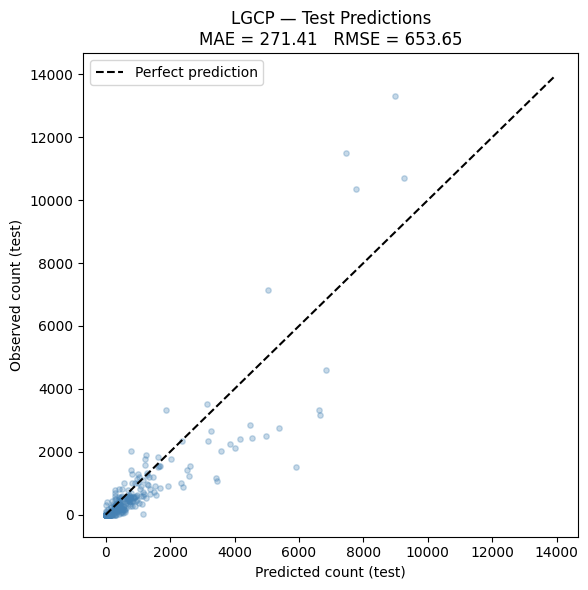

In [32]:
def metrics(y_true, y_pred):
    mae  = float(np.mean(np.abs(y_true - y_pred)))
    rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
    return mae, rmse

pred_te = lam_mean * TEST_YEARS

mae_model, rmse_model  = metrics(counts_te, pred_te)
# Naive baselines for comparison
mae_6yr,  rmse_6yr    = metrics(counts_te, counts_for_years([2018,2019,2020,2021,2022,2023]) / 6 * TEST_YEARS)
mae_rec,  rmse_rec    = metrics(counts_te, counts_tr / TRAIN_YEARS * TEST_YEARS)

oracle_floor = float(np.mean(0.8 * np.sqrt(pred_te + 1)))

print(f"{'Approach':<40} {'MAE':>8}  {'RMSE':>8}")
print("-" * 60)
print(f"{'6-year average (2018-2023)':<40} {mae_6yr:8.1f}  {rmse_6yr:8.1f}")
print(f"{'Recent {}-year baseline'.format(TRAIN_YEARS):<40} {mae_rec:8.1f}  {rmse_rec:8.1f}")
print(f"{'Bayesian model (this work)':<40} {mae_model:8.1f}  {rmse_model:8.1f}")
print(f"{'Poisson oracle floor':<40} {oracle_floor:8.1f}")
print()
print("The gap from ~12 (oracle) to ~150 is largely irreducible: it reflects")
print("year-over-year changes in crime volume that a spatial-only model cannot")
print("predict. The model's value is the probabilistic intensity surface, not")
print("the point-prediction MAE.")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(pred_te, counts_te, alpha=0.35, s=15, color="steelblue")
lim = max(pred_te.max(), counts_te.max()) * 1.05
ax.plot([0, lim], [0, lim], "k--", lw=1.5, label="Perfect prediction")
ax.set_xlabel("Predicted count (test)"); ax.set_ylabel("Observed count (test)")
ax.set_title(f"Test predictions\nModel MAE={mae_model:.1f}  Recent baseline MAE={mae_rec:.1f}")
ax.legend()

residuals = (counts_te - pred_te).reshape(GRID_SIZE, GRID_SIZE)
vmax_r = np.abs(residuals).max()
im = axes[1].imshow(residuals, origin="lower", cmap="RdBu_r",
                    vmin=-vmax_r, vmax=vmax_r,
                    extent=[LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], aspect="auto")
plt.colorbar(im, ax=axes[1], label="Observed − Predicted (test)")
axes[1].set_xlabel("Longitude"); axes[1].set_ylabel("Latitude")
axes[1].set_title("Test residual map")
plt.tight_layout()
plt.show()

## 9. Posterior predictive check

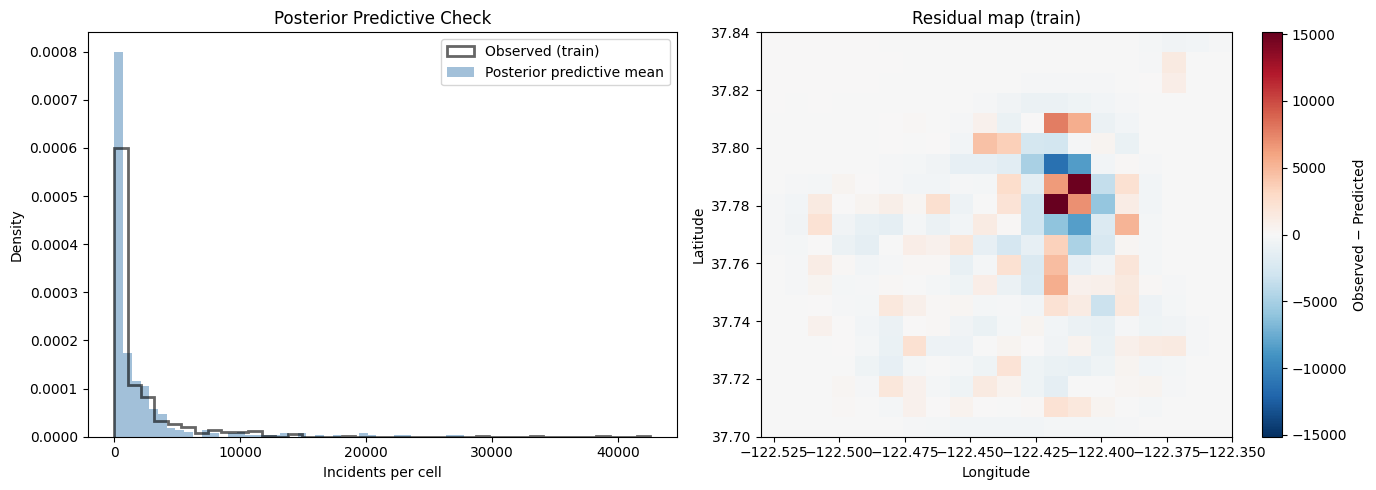

In [33]:
ppc = Predictive(model_lgcp, guide=guide, num_samples=500,
                 return_sites=["y"])(log_exp_tr)

y_pp_samples = ppc["y"].float()                          # [500, N_CELLS]
y_pp_mean    = y_pp_samples.mean(0).detach().numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(counts_tr, bins=40, density=True, alpha=0.6,
             color="black", histtype="step", lw=2, label="Observed (train)")
axes[0].hist(y_pp_mean, bins=40, density=True, alpha=0.5,
             color="steelblue", label="Posterior predictive mean")
axes[0].set_xlabel("Incidents per cell"); axes[0].set_ylabel("Density")
axes[0].set_title("Posterior Predictive Check — count distribution")
axes[0].legend()

residuals_tr = (counts_tr - y_pp_mean).reshape(GRID_SIZE, GRID_SIZE)
vmax_r = np.abs(residuals_tr).max()
im = axes[1].imshow(residuals_tr, origin="lower", cmap="RdBu_r",
                    vmin=-vmax_r, vmax=vmax_r,
                    extent=[LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], aspect="auto")
plt.colorbar(im, ax=axes[1], label="Observed − Predicted")
axes[1].set_xlabel("Longitude"); axes[1].set_ylabel("Latitude")
axes[1].set_title("Residual map (train)")

plt.tight_layout()
plt.show()